# Dataset Overview

Statistical summary of the SnowPyt-MechParams input dataset: snow pit inventory,
layer completeness, weak layer characteristics, and temperature observations.

## Table of Contents

1. [Setup & Data Loading](#1-setup--data-loading)
2. [Dataset Overview](#2-dataset-overview)
3. [Layer Completeness](#3-layer-completeness)
4. [Weak Layer Characteristics](#4-weak-layer-characteristics)

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import pandas as pd

from snowpyt_mechparams.snowpilot import parse_caaml_directory

from notebook_utils import load_pits, hess_rcparams, SINGLE_COL, DOUBLE_COL, DPI

hess_rcparams()
FIGURES = 'figures'


## 1. Setup & Data Loading

In [10]:
pits = load_pits()
all_pits = parse_caaml_directory('data')  # raw SnowPit objects for legacy helpers

total_pits = len(pits)
total_layers = sum(len(p.layers) for p in pits)
print(f'Loaded {total_pits:,} snow pits ({total_layers:,} layers)')


Loaded 50,278 snow pits (371,429 layers)


## 2. Dataset Overview

In [11]:
# Collect pit-level statistics from raw SnowPit objects
pit_info = []
for pit in all_pits:
    pit_info.append({
        'pit_id': pit.core_info.pit_id,
        'user_id': pit.core_info.user.user_id,
        'country': pit.core_info.location.country,
        'slope_angle': pit.core_info.location.slope_angle,
        'pit_near_avalanche': pit.core_info.location.pit_near_avalanche,
        'pit_near_avalanche_location': pit.core_info.location.pit_near_avalanche_location,
        'num_ct':  len(pit.stability_tests.CT)  if pit.stability_tests.CT  else 0,
        'num_ect': len(pit.stability_tests.ECT) if pit.stability_tests.ECT else 0,
        'num_pst': len(pit.stability_tests.PST) if pit.stability_tests.PST else 0,
    })
pit_df = pd.DataFrame(pit_info)

print(f'Total pits:         {len(pit_df):>7,}')
print(f'Unique users:       {pit_df["user_id"].nunique():>7,}')
print(f'Unique countries:   {pit_df["country"].nunique():>7,}')
print()
print(f'Pits near avalanche: {pit_df["pit_near_avalanche"].sum():>6,} ({pit_df["pit_near_avalanche"].mean():.1%})')
pits_crown = (pit_df['pit_near_avalanche_location'] == 'crown').sum()
pits_flank = (pit_df['pit_near_avalanche_location'] == 'flank').sum()
print(f'  — on avalanche crown: {pits_crown:>4,} ({pits_crown/len(pit_df):.1%})')
print(f'  — on avalanche flank: {pits_flank:>4,} ({pits_flank/len(pit_df):.1%})')
print()
print(f'Total CT  results: {int(pit_df["num_ct"].sum()):>7,} (pits with CT: {(pit_df["num_ct"]>0).sum():,})')
print(f'Total ECT results: {int(pit_df["num_ect"].sum()):>7,} (pits with ECT: {(pit_df["num_ect"]>0).sum():,})')
print(f'Total PST results: {int(pit_df["num_pst"].sum()):>7,} (pits with PST: {(pit_df["num_pst"]>0).sum():,})')


Total pits:          50,278
Unique users:         5,381
Unique countries:        35

Pits near avalanche:  1,568 (100.0%)
  — on avalanche crown:  795 (1.6%)
  — on avalanche flank:  399 (0.8%)

Total CT  results:  51,599 (pits with CT: 28,959)
Total ECT results:  47,684 (pits with ECT: 34,327)
Total PST results:   6,213 (pits with PST: 5,154)


## 3. Layer Completeness

In [12]:
# Collect layer-level attribute coverage from raw SnowPit objects
layer_info = []
for pit in all_pits:
    for layer in pit.snow_profile.layers:
        gf = layer.grain_form_primary
        layer_info.append({
            'hardness': layer.hardness if layer.hardness else None,
            'primary_grain_form': gf.grain_form if gf else None,
            'primary_grain_size': (
                gf.grain_size_avg[0] if gf and gf.grain_size_avg and len(gf.grain_size_avg) > 0
                else None
            ),
        })
layer_df = pd.DataFrame(layer_info)

total_layers_raw = len(layer_df)
n_hardness   = layer_df['hardness'].notna().sum()
n_grain_form = layer_df['primary_grain_form'].notna().sum()
n_grain_size = layer_df['primary_grain_size'].notna().sum()

print(f'Total layers:         {total_layers_raw:>7,}')
print(f'With hand hardness:   {n_hardness:>7,} ({n_hardness/total_layers_raw:.1%})')
print(f'With grain form:      {n_grain_form:>7,} ({n_grain_form/total_layers_raw:.1%})')
print(f'With grain size:      {n_grain_size:>7,} ({n_grain_size/total_layers_raw:.1%})')


Total layers:         371,429
With hand hardness:   336,888 (90.7%)
With grain form:      303,726 (81.8%)
With grain size:      176,044 (47.4%)


## 4. Weak Layer Characteristics

Grain form distributions for ECTP failure layers (the primary weak layer dataset used
throughout this paper) compared with all indicated layers of concern.


In [13]:
import numpy as np

def get_value_safe(obj):
    if obj is None:
        return None
    if isinstance(obj, (list, tuple, np.ndarray)):
        return obj[0] if len(obj) > 0 else None
    return obj

def extract_layer_dict(layer, pit_id, dataset_name):
    return {
        'pit_id': pit_id,
        'dataset': dataset_name,
        'depth_top': get_value_safe(layer.depth_top),
        'thickness': get_value_safe(layer.thickness),
        'hardness': layer.hardness if layer.hardness else None,
        'grain_form': layer.grain_form_primary.grain_form if layer.grain_form_primary else None,
    }

def extract_layers_of_concern(raw_pits, filter_location=None):
    dataset_name = ({'crown': 'pits_on_crowns_loc', 'flank': 'pits_on_flanks_loc'}
                    .get(filter_location, 'all_pits_loc'))
    rows = []
    for pit in raw_pits:
        if filter_location and pit.core_info.location.pit_near_avalanche_location != filter_location:
            continue
        for layer in (pit.snow_profile.layers or []):
            if layer.layer_of_concern is True:
                rows.append(extract_layer_dict(layer, pit.core_info.pit_id, dataset_name))
    return pd.DataFrame(rows)

def extract_ectp_failure_layers(raw_pits):
    rows = []
    for pit in raw_pits:
        layers = pit.snow_profile.layers or []
        for test in pit.stability_tests.ECT:
            has_prop = (
                (hasattr(test, 'propagation') and test.propagation is True) or
                (hasattr(test, 'test_score') and test.test_score and 'ECTP' in str(test.test_score))
            )
            if not has_prop:
                continue
            test_depth = get_value_safe(test.depth_top)
            if test_depth is None:
                continue
            closest = min(
                layers,
                key=lambda l: abs(get_value_safe(l.depth_top) - test_depth)
                if get_value_safe(l.depth_top) is not None else float('inf'),
                default=None
            )
            if closest is not None:
                rows.append(extract_layer_dict(closest, pit.core_info.pit_id, 'ECTP_failure_layer'))
    return pd.DataFrame(rows)

loc_df  = extract_layers_of_concern(all_pits)
ectp_df = extract_ectp_failure_layers(all_pits)
print(f'Layers of concern:   {len(loc_df):>6,}')
print(f'ECTP failure layers: {len(ectp_df):>6,}')


Layers of concern:   36,409
ECTP failure layers: 15,247


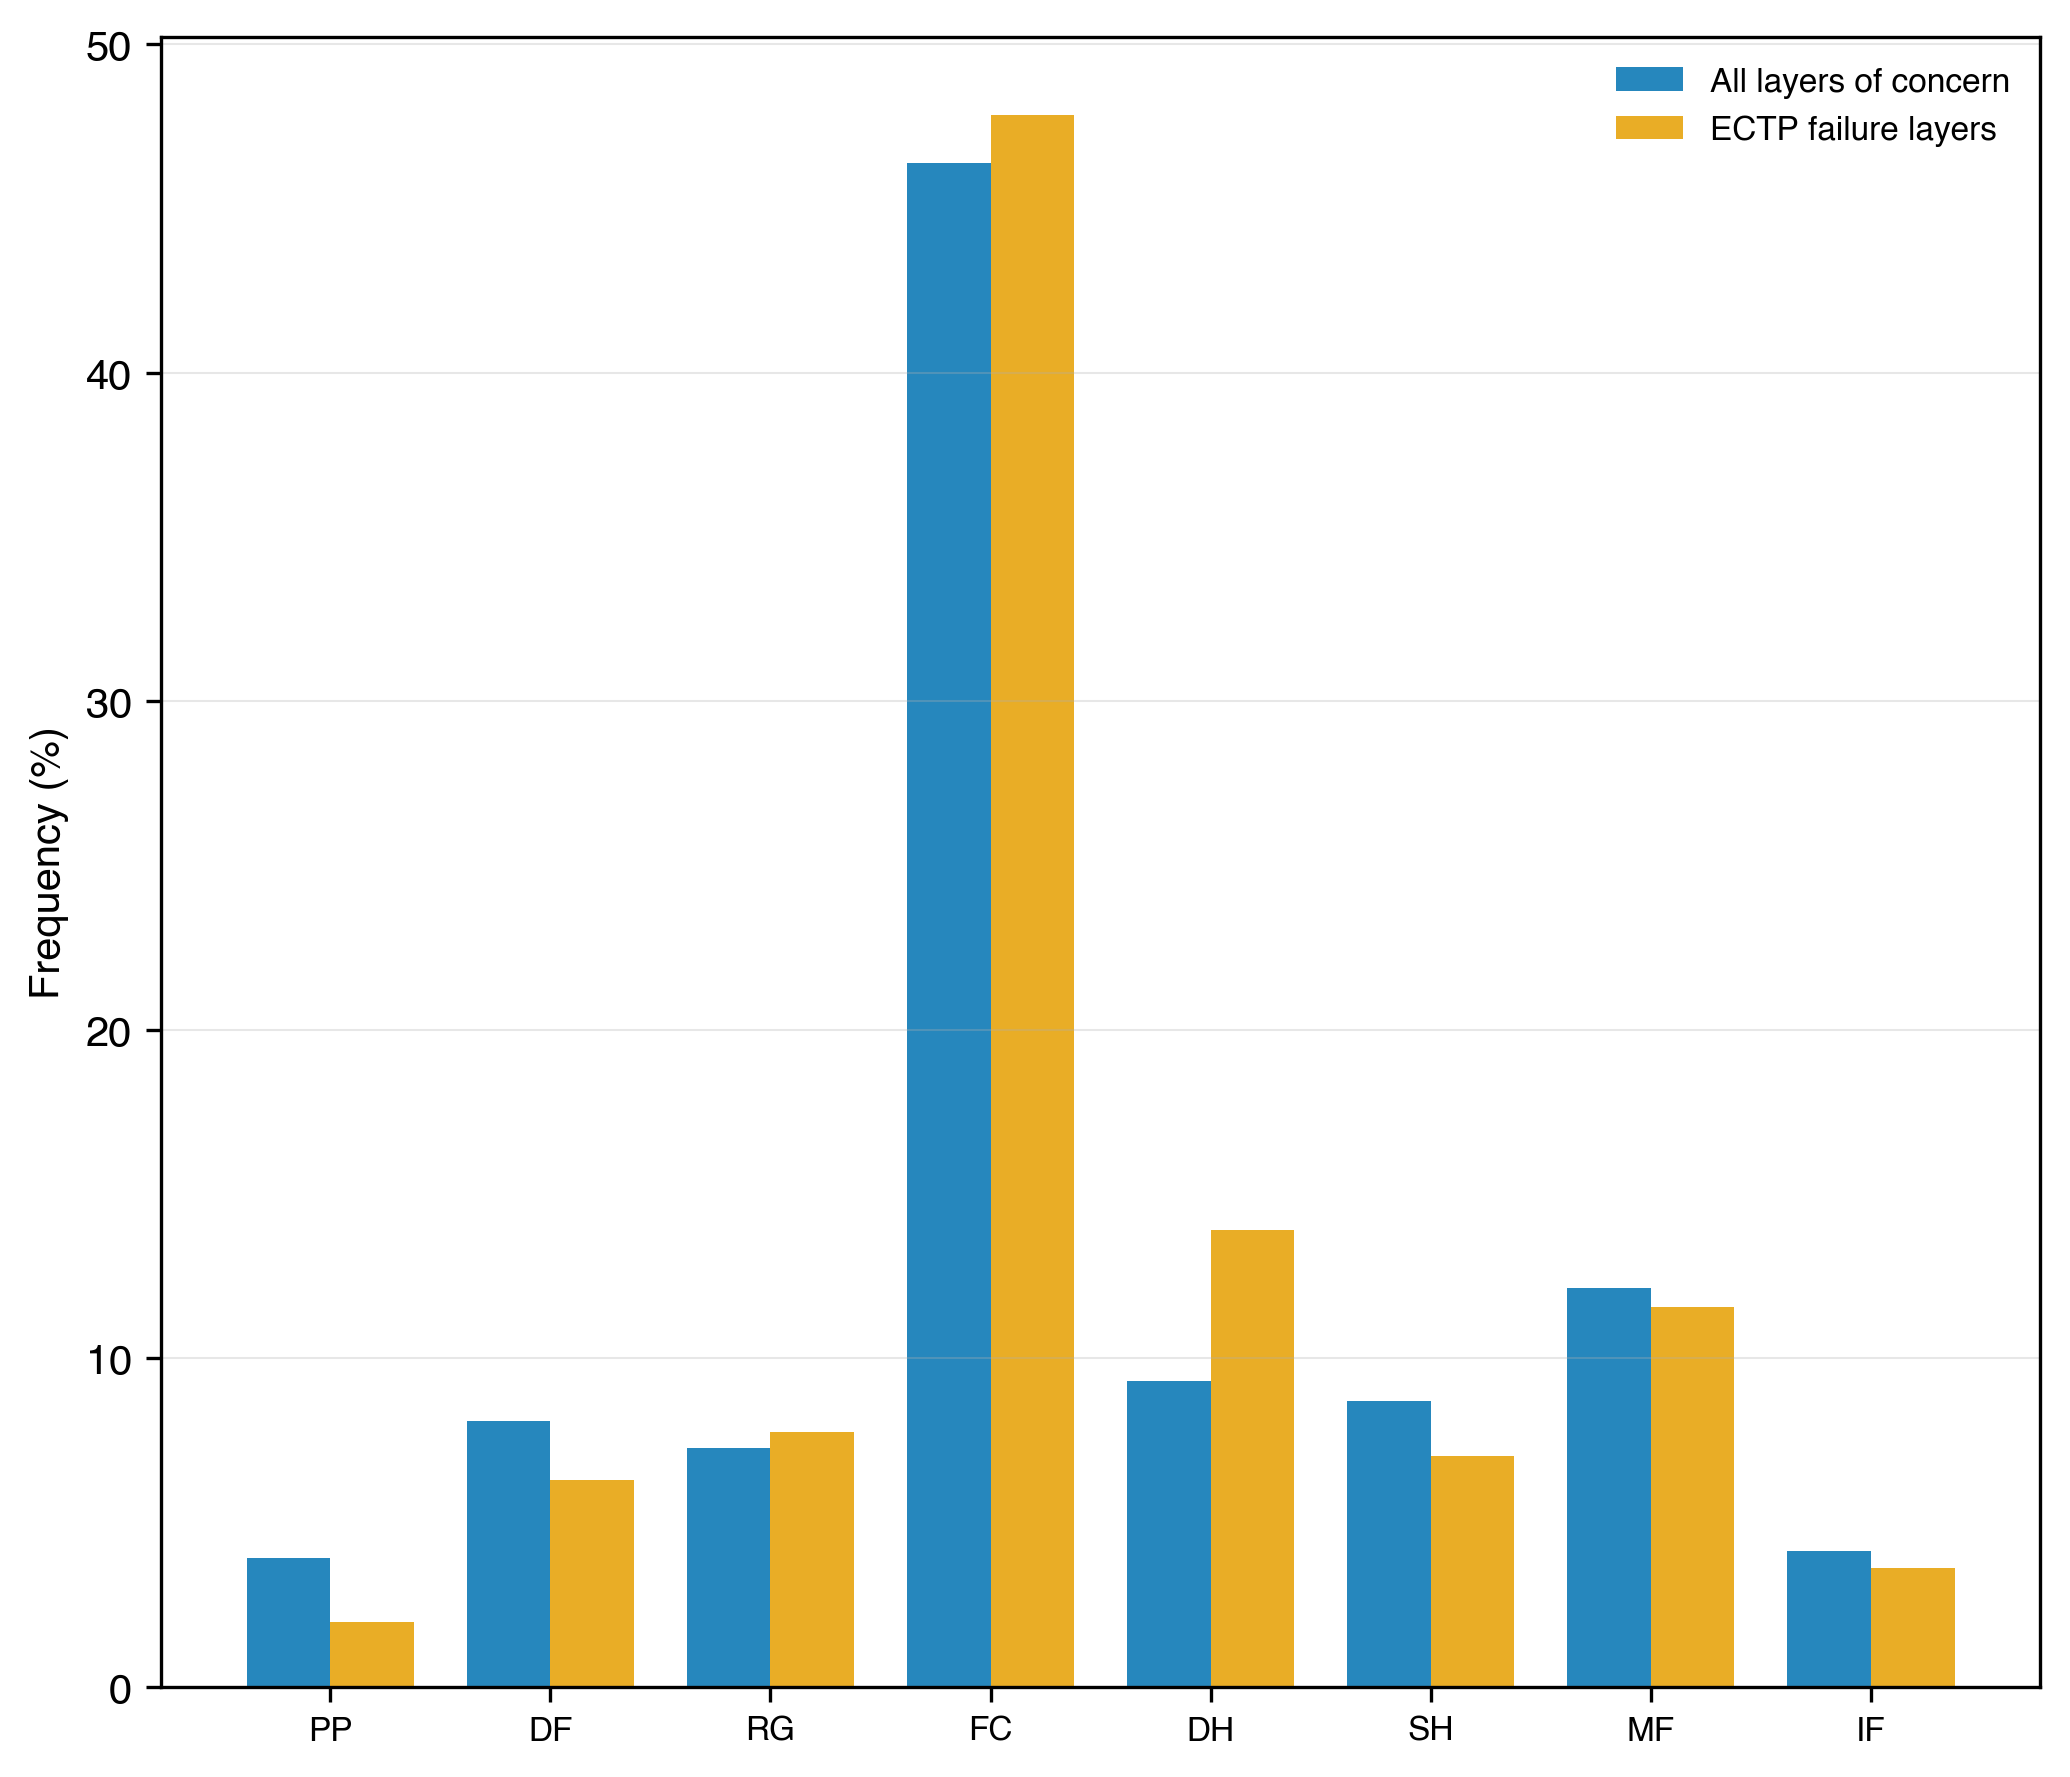

In [14]:
# Grain form frequency comparison: LOC vs ECTP failure layers
GRAIN_FORM_LABELS = {
    'PP': 'Precipitation particles (PP)',
    'DF': 'Decomposing / fragmented (DF)',
    'RG': 'Rounded grains (RG)',
    'FC': 'Faceted crystals (FC)',
    'DH': 'Depth hoar (DH)',
    'SH': 'Surface hoar (SH)',
    'MF': 'Melt forms (MF)',
    'IF': 'Ice formations (IF)',
}

def grain_form_counts(df):
    codes = df['grain_form'].dropna().str[:2]
    return codes.value_counts(normalize=True).reindex(GRAIN_FORM_LABELS.keys(), fill_value=0)

loc_pct  = grain_form_counts(loc_df)
ectp_pct = grain_form_counts(ectp_df)

x = np.arange(len(GRAIN_FORM_LABELS))
width = 0.38
fig, ax = plt.subplots(figsize=(DOUBLE_COL, SINGLE_COL * 1.8))
ax.bar(x - width/2, loc_pct.values  * 100, width, label='All layers of concern', color='#0072B2', alpha=0.85)
ax.bar(x + width/2, ectp_pct.values * 100, width, label='ECTP failure layers',   color='#E69F00', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(list(GRAIN_FORM_LABELS.keys()), fontsize=8)
ax.set_ylabel('Frequency (%)')
ax.legend(fontsize=8, frameon=False)
ax.grid(axis='y', alpha=0.3, linewidth=0.5)
fig.tight_layout()
fig.savefig(f'{FIGURES}/dataset_overview_grain_form.png', dpi=DPI, bbox_inches='tight')
plt.show()
